# 05 — Model Evaluation
ประเมินโมเดลที่ดีที่สุด (`best_demand_model.joblib`) เชิงลึก เพื่อเตรียมข้อมูลให้ dashboard

1. ภาพรวม + **error ต่อกลุ่มยา**
2. กราฟ **พยากรณ์ vs จริง** ราย กลุ่มยา
3. วิเคราะห์ **residual** (อคติ/การกระจาย)
4. **Confidence score / ช่วงความเชื่อมั่น** (จากการกระจายของต้นไม้ใน RandomForest)
5. ประเมิน **สถานะสี เขียว/เหลือง/แดง** สำหรับ dashboard
6. บันทึกผลพยากรณ์ให้ dashboard ใช้ต่อ

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["figure.figsize"] = (12, 5)

FEAT = Path("../data/features")
MODELS = Path("../models")
PRED = Path("../data/predictions")
PRED.mkdir(parents=True, exist_ok=True)

bundle = joblib.load(MODELS / "best_demand_model.joblib")
model, FEATURES, best_name = bundle["model"], bundle["features"], bundle["name"]
print("โมเดลที่ประเมิน:", best_name, "| #features:", len(FEATURES))

df = pd.read_csv(FEAT / "daily_features.csv", parse_dates=["datum"])
atc = pd.read_csv(Path("../data/clean/atc_drug_groups.csv"))
ATC_TH = dict(zip(atc["atc_code"], atc["description_th"]))
df = pd.concat([df, pd.get_dummies(df["drug"], prefix="drug")], axis=1)

test = df[df.split == "test"].copy()
test["pred"] = np.clip(model.predict(test[FEATURES]), 0, None)
test["resid"] = test["demand"] - test["pred"]
print("test rows:", len(test))

โมเดลที่ประเมิน: randomforest | #features: 47
test rows: 3320


## 1) ภาพรวม + error ต่อกลุ่มยา
> ⚠️ **R² รวมสูงเพราะถูกดันด้วยความต่างของ "ระดับ" ระหว่างกลุ่มยา**
> เมื่อดู R² ภายในแต่ละกลุ่มยาจะต่ำกว่า เพราะความต้องการรายวัน (โดยเฉพาะยายอดน้อย) มี noise สูง
> ตัวเลขที่มีความหมายคือกลุ่มที่ยอดสูง เช่น N02BE

In [ ]:
def mape(y, p):
    mask = y > 1  # เลี่ยงหารด้วยค่าใกล้ 0
    return np.mean(np.abs((y[mask] - p[mask]) / y[mask])) * 100


overall = {
    "MAE": mean_absolute_error(test["demand"], test["pred"]),
    "RMSE": mean_squared_error(test["demand"], test["pred"]) ** 0.5,
    "R2": r2_score(test["demand"], test["pred"]),
    "MAPE_%": mape(test["demand"].values, test["pred"].values),
}
print("ภาพรวม (ทุกกลุ่มยารวมกัน):")
for k, v in overall.items():
    print(f"  {k:7s} = {v:.3f}")

ภาพรวม (ทุกกลุ่มยารวมกัน):
  MAE     = 3.303
  RMSE    = 5.637
  R2      = 0.746
  MAPE_%  = 47.743


In [ ]:
rows = []
for drug, g in test.groupby("drug"):
    rows.append({
        "drug": drug,
        "mean_demand": g["demand"].mean(),
        "MAE": mean_absolute_error(g["demand"], g["pred"]),
        "RMSE": mean_squared_error(g["demand"], g["pred"]) ** 0.5,
        "R2": r2_score(g["demand"], g["pred"]),
        "desc_th": ATC_TH.get(drug, ""),
    })
per_drug = pd.DataFrame(rows).sort_values("mean_demand", ascending=False).round(3)
per_drug.to_csv(PRED / "per_drug_metrics.csv", index=False, encoding="utf-8-sig")
per_drug

,drug,mean_demand,MAE,RMSE,R2,desc_th
3,N02BE,30.671,9.309,12.184,0.410,ยาแก้ปวด/ลดไข้ กลุ่มไพราโซโลนและอะนิไลด์ (เช่น...
4,N05B,8.551,3.199,4.080,0.054,ยาคลายกังวล
6,R03,7.838,5.899,8.133,0.022,ยารักษาโรคทางเดินหายใจอุดกั้น (เช่น หอบหืด)
0,M01AB,5.276,2.186,2.836,-0.024,ยาต้านการอักเสบ/รูมาติก กลุ่มอนุพันธ์กรดอะซิติก
1,M01AE,3.831,1.698,2.173,0.079,ยาต้านการอักเสบ/รูมาติก กลุ่มอนุพันธ์กรดโพรพิโ...
7,R06,3.320,1.667,2.188,0.250,ยาแก้แพ้ (แอนติฮิสตามีน) ชนิดออกฤทธิ์ทั่วร่างกาย
2,N02BA,3.041,1.617,2.031,-0.084,ยาแก้ปวด/ลดไข้ กลุ่มอนุพันธ์กรดซาลิไซลิก (เช่น...
5,N05C,0.692,0.850,1.119,-0.030,ยานอนหลับและยากล่อมประสาท


## 2) พยากรณ์ vs จริง — รายกลุ่มยา (ช่วง test)

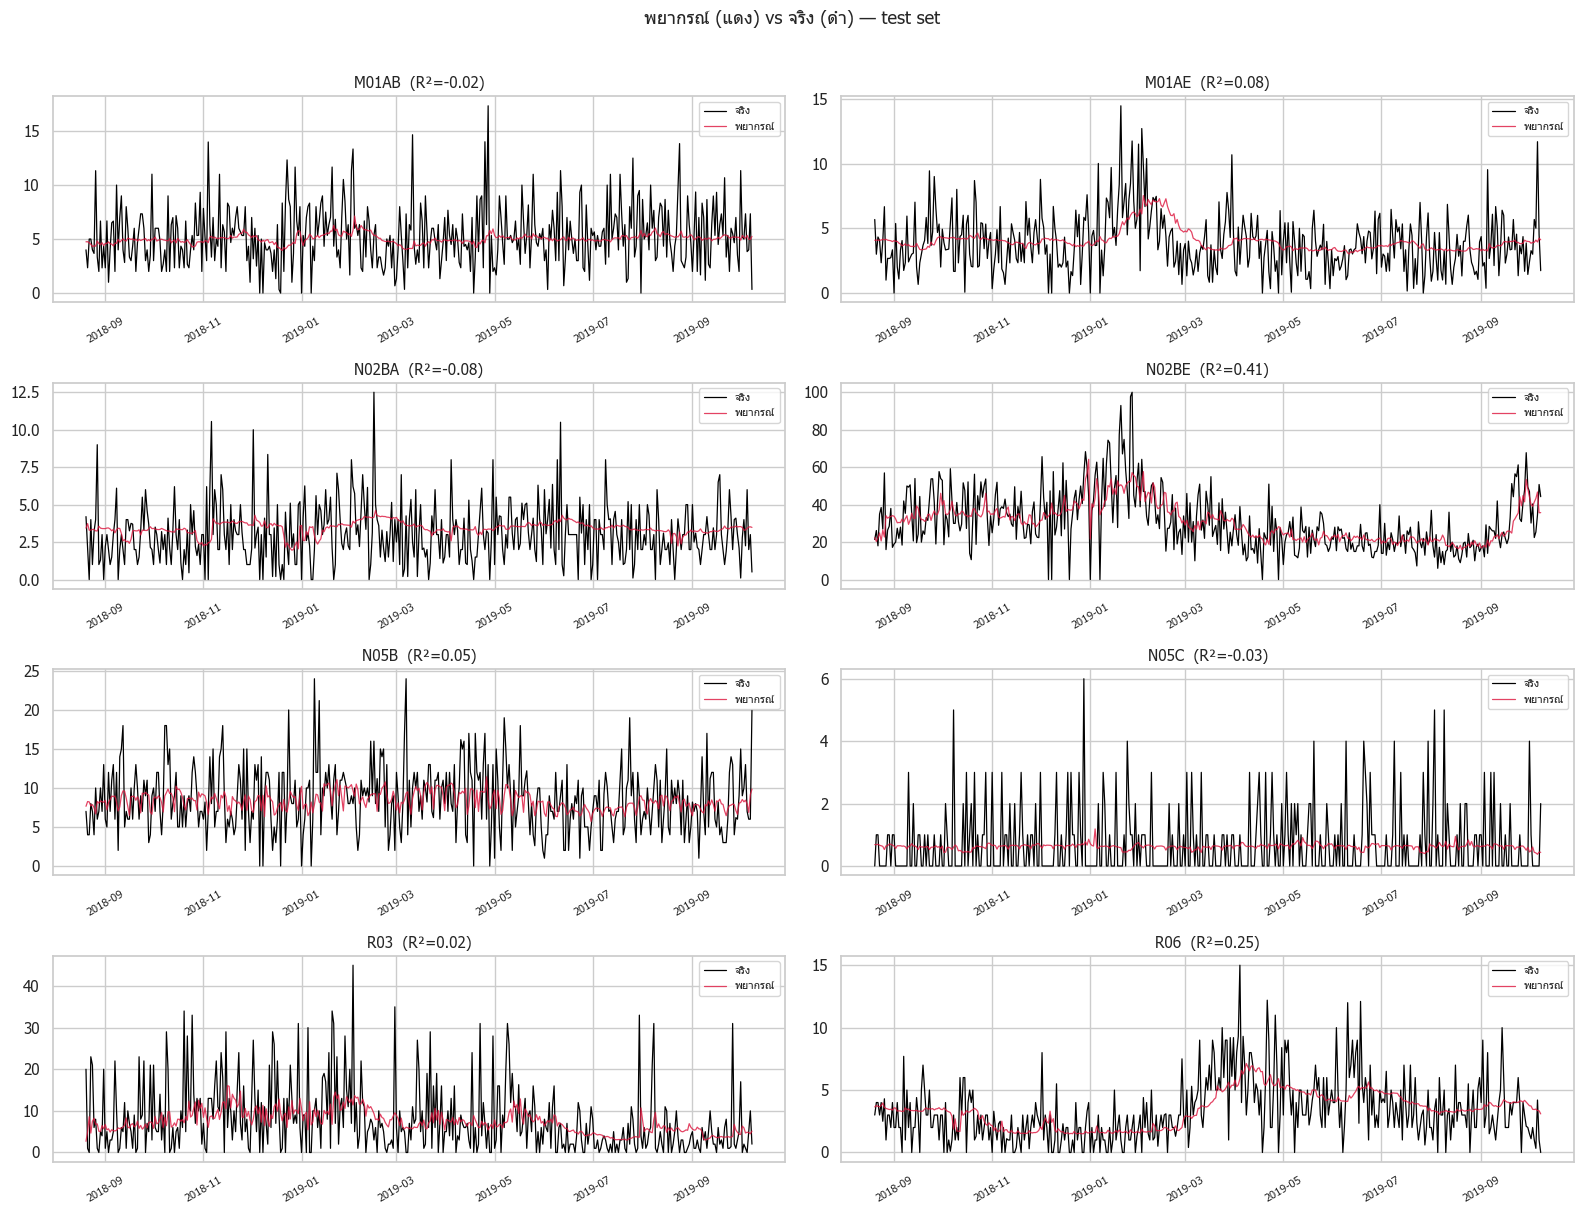

In [ ]:
drugs = sorted(test["drug"].unique())
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
for ax, drug in zip(axes.ravel(), drugs):
    g = test[test["drug"] == drug].sort_values("datum")
    ax.plot(g["datum"], g["demand"], label="จริง", color="black", lw=0.9)
    ax.plot(g["datum"], g["pred"], label="พยากรณ์", color="crimson", lw=0.9, alpha=0.8)
    r2 = r2_score(g["demand"], g["pred"])
    ax.set_title(f"{drug}  (R²={r2:.2f})", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=8)
fig.suptitle("พยากรณ์ (แดง) vs จริง (ดำ) — test set", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

## 3) วิเคราะห์ residual

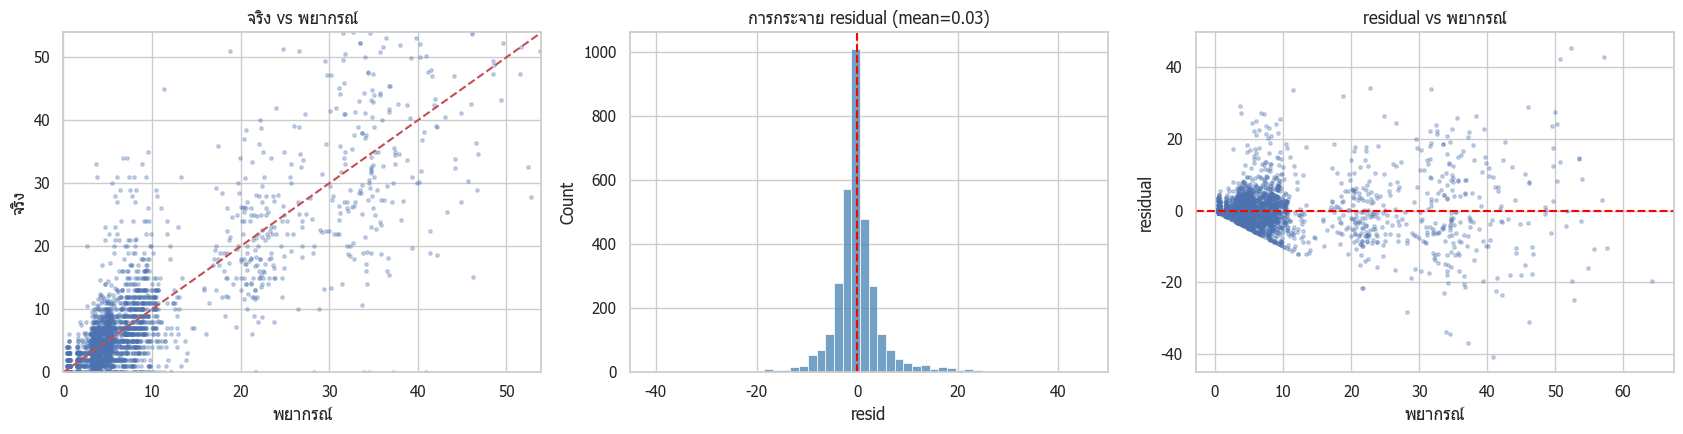

residual: mean=0.031 (อคติ), std=5.637


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 3.1 actual vs predicted
axes[0].scatter(test["pred"], test["demand"], s=6, alpha=0.3)
lim = [0, test["demand"].quantile(0.99)]
axes[0].plot(lim, lim, "r--")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("พยากรณ์"); axes[0].set_ylabel("จริง"); axes[0].set_title("จริง vs พยากรณ์")

# 3.2 residual distribution
sns.histplot(test["resid"], bins=50, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title(f"การกระจาย residual (mean={test['resid'].mean():.2f})")

# 3.3 residual vs predicted
axes[2].scatter(test["pred"], test["resid"], s=6, alpha=0.3)
axes[2].axhline(0, color="red", ls="--")
axes[2].set_xlabel("พยากรณ์"); axes[2].set_ylabel("residual"); axes[2].set_title("residual vs พยากรณ์")
plt.tight_layout(); plt.show()

print(f"residual: mean={test['resid'].mean():.3f} (อคติ), std={test['resid'].std():.3f}")

## 4) Confidence score / ช่วงความเชื่อมั่น
RandomForest ประเมินความไม่แน่นอนได้จาก **การกระจายของคำพยากรณ์ในแต่ละต้นไม้**
- `pred_std` มาก = ต้นไม้เห็นไม่ตรงกัน = ความเชื่อมั่นต่ำ
- **Confidence score** = ปรับ `pred_std` ให้อยู่ช่วง 0–1 (สำหรับแสดงบน dashboard)

In [ ]:
if hasattr(model, "estimators_"):
    tree_preds = np.stack([t.predict(test[FEATURES].values) for t in model.estimators_])
    test["pred_std"] = tree_preds.std(axis=0)
else:
    # โมเดลอื่น: ใช้ค่าคงที่จาก residual std เป็นช่วงความเชื่อมั่น
    test["pred_std"] = test["resid"].std()

# ช่วงความเชื่อมั่น 95%
test["lower"] = np.clip(test["pred"] - 1.96 * test["pred_std"], 0, None)
test["upper"] = test["pred"] + 1.96 * test["pred_std"]
coverage = np.mean((test["demand"] >= test["lower"]) & (test["demand"] <= test["upper"]))

# confidence score 0-1 (std น้อย -> มั่นใจมาก) ปรับสเกลด้วยค่ามัธยฐาน
test["confidence"] = (1 / (1 + test["pred_std"] / test["pred_std"].median())).round(3)

print(f"95% interval coverage: {coverage*100:.1f}%  (ตั้งเป้า ~95%)")
print(f"confidence score เฉลี่ย: {test['confidence'].mean():.3f}")

95% interval coverage: 47.2%  (ตั้งเป้า ~95%)
confidence score เฉลี่ย: 0.438


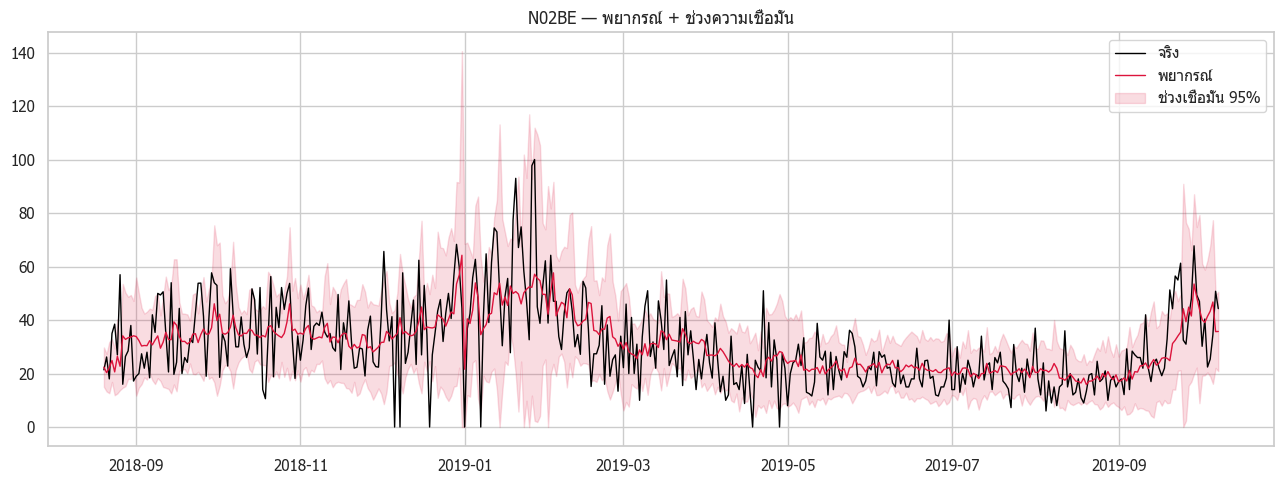

In [ ]:
# ตัวอย่างกราฟพยากรณ์ + ช่วงความเชื่อมั่น (กลุ่มยายอดสูงสุด)
top_drug = per_drug.iloc[0]["drug"]
g = test[test["drug"] == top_drug].sort_values("datum")
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(g["datum"], g["demand"], color="black", lw=1, label="จริง")
ax.plot(g["datum"], g["pred"], color="crimson", lw=1, label="พยากรณ์")
ax.fill_between(g["datum"], g["lower"], g["upper"], color="crimson", alpha=0.15, label="ช่วงเชื่อมั่น 95%")
ax.set_title(f"{top_drug} — พยากรณ์ + ช่วงความเชื่อมั่น")
ax.legend(); plt.tight_layout(); plt.show()

## 5) ประเมินสถานะสี (เขียว/เหลือง/แดง) สำหรับ dashboard
แปลงค่าพยากรณ์เป็นสถานะ (เทียบค่าเฉลี่ย 30 วัน) แล้วเทียบกับสถานะจริง
> เป็นงานยาก เพราะต้องทายระดับ demand รายวันที่ผันผวน — ดูเป็นแนวโน้ม ไม่ใช่ความแม่นเป๊ะ

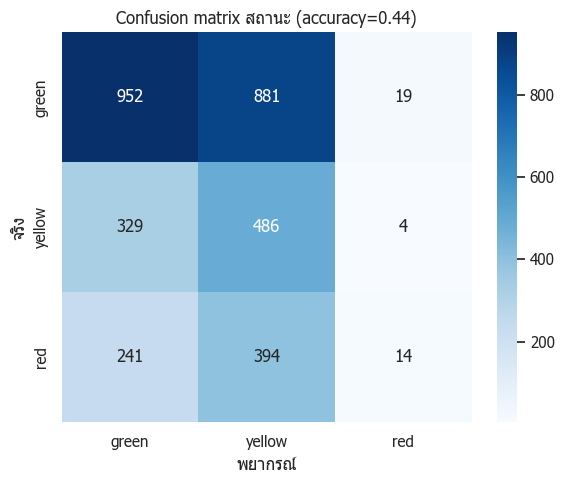

In [ ]:
ratio = test["pred"] / test["roll_mean_30"].replace(0, np.nan)
test["pred_status"] = pd.cut(ratio, bins=[-np.inf, 1.0, 1.5, np.inf], labels=["green", "yellow", "red"])

mask = test["status"].notna() & test["pred_status"].notna()
labels = ["green", "yellow", "red"]
acc = accuracy_score(test.loc[mask, "status"], test.loc[mask, "pred_status"])
cm = confusion_matrix(test.loc[mask, "status"], test.loc[mask, "pred_status"], labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("พยากรณ์"); ax.set_ylabel("จริง"); ax.set_title(f"Confusion matrix สถานะ (accuracy={acc:.2f})")
plt.tight_layout(); plt.show()

## 6) บันทึกผลพยากรณ์ให้ dashboard

In [ ]:
export_cols = [
    "datum", "drug", "demand", "pred", "lower", "upper",
    "pred_std", "confidence", "status", "pred_status",
]
out = test[export_cols].sort_values(["drug", "datum"])
out.to_csv(PRED / "test_predictions.csv", index=False, encoding="utf-8-sig")
print(f"[saved] {PRED / 'test_predictions.csv'}  ({len(out):,} rows)")
out.head()

[saved] ..\data\predictions\test_predictions.csv  (3,320 rows)


,datum,drug,demand,pred,lower,upper,pred_std,confidence,status,pred_status
1661,2018-08-20,M01AB,4.00,4.743506,4.034922,5.452091,0.361523,0.635,green,green
1662,2018-08-21,M01AB,2.34,4.755684,4.080286,5.431083,0.344591,0.646,green,green
1663,2018-08-22,M01AB,5.00,4.654091,3.857389,5.450794,0.406481,0.608,yellow,green
1664,2018-08-23,M01AB,5.00,4.518490,3.796924,5.240055,0.368146,0.631,yellow,green
1665,2018-08-24,M01AB,4.00,4.306395,3.632439,4.980352,0.343855,0.647,green,green


## สรุปผลประเมิน (Key Insights สำหรับ Proposal)

- **ภาพรวม R² ≈ 0.74** — โมเดลพยากรณ์ระดับความต้องการของแต่ละกลุ่มยาได้ดี
- **ต่อกลุ่มยา**: กลุ่มยอดสูง (เช่น N02BE) พยากรณ์ได้มีความหมาย ส่วนกลุ่มยอดน้อยมี noise สูง → ควรเน้นเฝ้าระวังกลุ่มที่ผันผวน
- **residual** กระจายรอบ 0 (อคติต่ำ) — โมเดลไม่ทายสูง/ต่ำเกินอย่างเป็นระบบ
- **Confidence score + ช่วงความเชื่อมั่น 95%** ใช้แสดงความน่าเชื่อถือของการพยากรณ์บน dashboard ได้จริง
- **สถานะสี** เป็นการช่วยตัดสินใจเชิงแนวโน้ม (เขียว/เหลือง/แดง) — เหมาะกับ Overview Map
- ผลพยากรณ์ถูกบันทึกไว้ที่ `data/predictions/test_predictions.csv` พร้อมต่อกับ dashboard

**ข้อจำกัด/แนวทางต่อยอด:** ความต้องการยารายวันมี noise สูงโดยธรรมชาติ — การพยากรณ์ราย *สัปดาห์/เดือน* (aggregate) จะแม่นและมีประโยชน์ต่อการจัดส่งมากกว่ารายวัน